<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/CIFAR_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense,Conv2D,Flatten,Dropout, GlobalMaxPooling2D,MaxPooling2D,BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

In [3]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()
x_train,x_test = x_train/255.0,x_test/255.0
y_train,y_test = y_train.flatten(),y_test.flatten()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
y_train.shape

(50000,)

In [6]:
y_test.shape

(10000,)

In [7]:
# number of classes

k = len(set(y_train))
print('number of classes: ', k )

number of classes:  10


In [8]:
# data augmentation

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [11]:
# Build the model using the functional API

i = Input(shape =x_train[0].shape)

#data augmentation
x = data_aug(i)

#other layers

x = Conv2D(32,(3,3),activation = 'relu',padding = 'same')(x)
x = BatchNormalization()(x)
x = Conv2D(32,(3,3),activation = 'relu',padding = 'same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64,(3,3),activation = 'relu',padding = 'same')(x)
x = BatchNormalization()(x)
x = Conv2D(64,(3,3),activation = 'relu',padding = 'same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128,(3,3),activation = 'relu',padding = 'same')(x)
x = BatchNormalization()(x)
x = Conv2D(128,(3,3),activation = 'relu',padding = 'same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(1024,activation = 'relu')(x)
x = Dropout(0.2)(x)
x = Dense(k,activation = 'softmax')(x)

model = Model(i,x)

In [12]:
# compile

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [13]:
r = model.fit(x_train,y_train,validation_data = (x_test,y_test),epochs = 50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.3789 - loss: 1.9651 - val_accuracy: 0.4660 - val_loss: 1.5936
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.5648 - loss: 1.2324 - val_accuracy: 0.6481 - val_loss: 1.0165
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6369 - loss: 1.0413 - val_accuracy: 0.6891 - val_loss: 0.9055
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.6692 - loss: 0.9544 - val_accuracy: 0.6491 - val_loss: 1.1094
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7013 - loss: 0.8733 - val_accuracy: 0.7150 - val_loss: 0.8619
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7182 - loss: 0.8147 - val_accuracy: 0.7454 - val_loss: 0.7654
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.7413 - loss: 0.7632 - val_accuracy: 0.7643 - val_loss: 0.6975
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.7566 -

In [14]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8573 - loss: 0.4392


[0.44193559885025024, 0.8583999872207642]

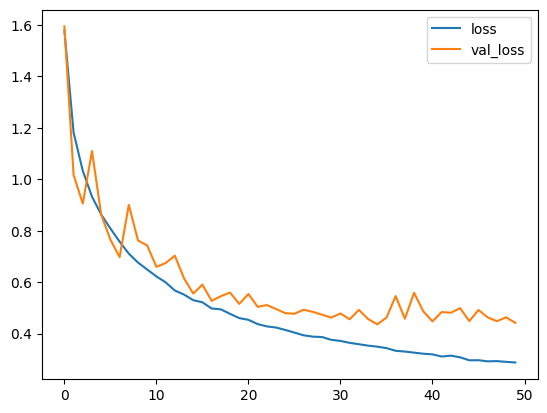

In [16]:
plt.plot(r.history['loss'],label = 'loss')
plt.plot(r.history['val_loss'],label = 'val_loss')
plt.legend()

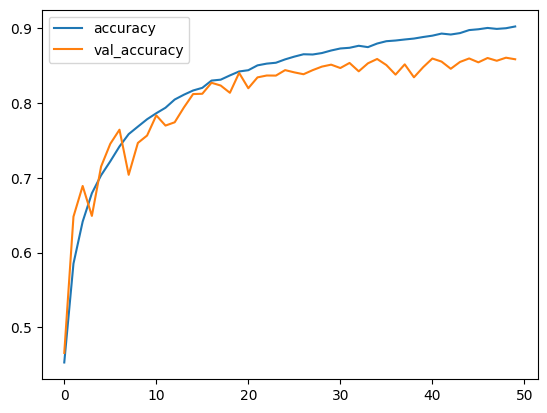

In [17]:
plt.plot(r.history['accuracy'],label = 'accuracy')
plt.plot(r.history['val_accuracy'],label = 'val_accuracy')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


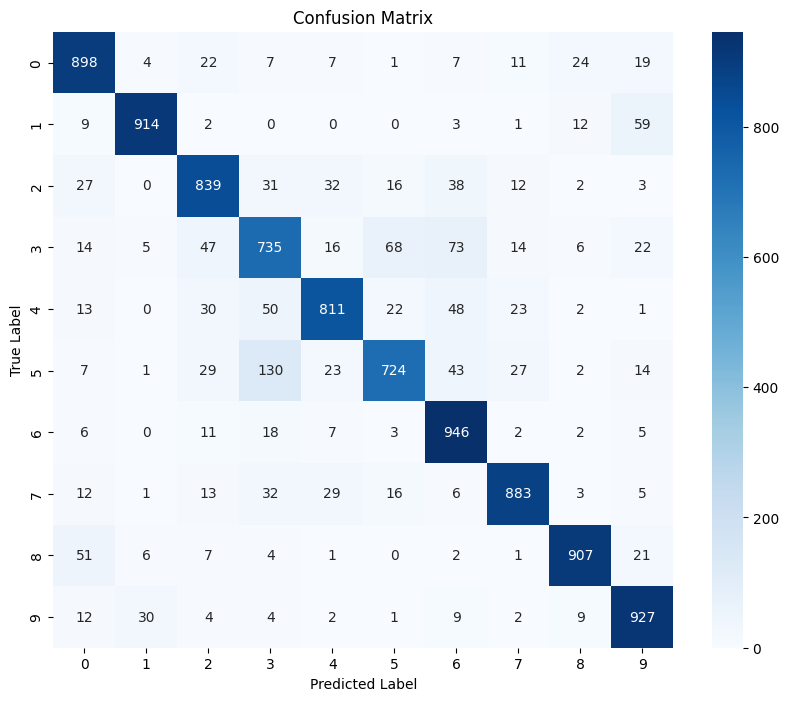

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
labels = '''airplane
automobile
bird
car
deer
dog
frog
horse
ship
truck'''.split()

Text(0.5, 1.0, 'True- label: frog predicted car')

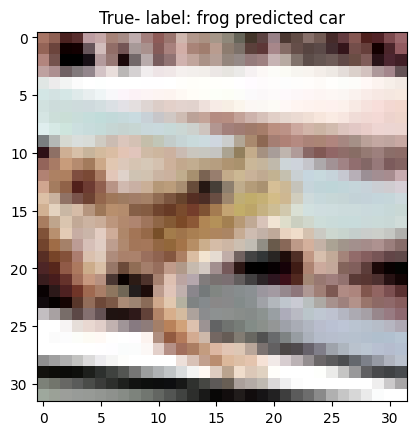

In [22]:
miscellided_idx = np.where(y_pred_classes != y_test)[0]
i = np.random.choice(miscellided_idx)
plt.imshow(x_test[i],cmap = 'gray')
plt.title('True- label: %s predicted %s' % (labels[y_test[i]], labels[y_pred_classes[i]]))

In [23]:
# Create tensorflow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))